In [1]:
import sys
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from matplotlib.colors import LinearSegmentedColormap

%load_ext autoreload
%autoreload 2

sys.path.insert(0, "..")
from plasmidtools import examplots, helpers


Paths

In [2]:
DATA_DIR = Path("../data")
FIG_DIR = DATA_DIR / "figures"
ADDGENE_DIR = DATA_DIR / "addgene"
GBK_DIR = DATA_DIR / "genbank"


Pre-processed data

In [3]:
plasmid_meta = pl.read_csv(ADDGENE_DIR / "mammalian_plasmids.tsv", separator="\t")
plasmid_citations = pl.read_parquet(ADDGENE_DIR / "citations_addgene.parquet")
plasmid_stats = (
    pl.read_parquet(ADDGENE_DIR / "mammalian_plasmids_statistics.parquet")
    .join(plasmid_meta[["sequence_id", "plasmid_id", "plasmid_name"]], on="sequence_id", how="left")
)

cre_annotation = pl.read_parquet(ADDGENE_DIR / "mammalian_plasmids_cre_and_tss.parquet")


Pre-calculated predictions

In [4]:
CREST_TILE_ENCOD = ADDGENE_DIR / "mammalian_plasmids_crest_encodings.parquet"
CREST_TILE_PREDS = ADDGENE_DIR / "mammalian_plasmids_crest_preds.parquet"
CELL_TYPES = ["HEK293T", "A549", "MRC5", "SHSY5Y", "K562", "GM12878", "Jurkat"]

PUFFIN_PREDS = ADDGENE_DIR / "mammalian_plasmids_puffin_preds.h5"

# Load CREST predictions
tile_encoding = pl.read_parquet(CREST_TILE_ENCOD)
cre_predictions = pl.read_parquet(CREST_TILE_PREDS)
n_crest_tiles = tile_encoding["tile_ids"].list.max().max() + 1
crest_pred_dct = {}
for cell in CELL_TYPES:
    tile_preds = np.full(n_crest_tiles, np.nan)
    tile_preds[cre_predictions["tile_ID"].to_numpy()] = cre_predictions[cell].to_numpy()
    crest_pred_dct[cell] = tile_preds

# Load Puffin indices
with h5py.File(PUFFIN_PREDS, "r") as h5f:
    puffin_feat_names = h5f.attrs["features"]
    puffin_fwd_idx = int(np.argwhere(puffin_feat_names == "FANTOM_CAGE fwd")[0, 0])
    puffin_rev_idx = int(np.argwhere(puffin_feat_names == "FANTOM_CAGE rev")[0, 0])


### Visualization of predictions

Load plasmid data: genbank, CREST predictions, Puffin predictions

In [5]:
# Extract plasmid GBK to a separate file
COMBINED_GBK = ADDGENE_DIR / "mammalian_plasmids.gbk"
gbk_name = plasmid_stats.filter(pl.col("plasmid_id") == 99297)["gbk_name"][0]  # NOTE: 99297
gbk_file = GBK_DIR / f"{gbk_name}.gbk"
helpers.extract_genbank_record_by_name(COMBINED_GBK, gbk_name, gbk_file)

# Plasmid CREST predictions
tile_ids_plasmid = tile_encoding.filter(pl.col("gbk_name") == gbk_name)["tile_ids"][0]
plasmid_crest_preds = {cell: preds[tile_ids_plasmid] for cell, preds in crest_pred_dct.items()}

# Plasmid Puffin predictions
with h5py.File(PUFFIN_PREDS, "r") as h5f:
    puffin_preds = h5f[gbk_name][:]
    puffin_fwd_preds = puffin_preds[puffin_fwd_idx]
    puffin_rev_preds = puffin_preds[puffin_rev_idx]

# Peaks (CREs and TSSs)
plasmid_peaks = cre_annotation.filter(pl.col("gbk_name") == gbk_name)
plasmid_crest_peaks = {cell: plasmid_peaks[f"CREST ({cell})"].to_list() for cell in CELL_TYPES}
plasmid_fwd_tss = plasmid_peaks["Puffin (FANTOM_CAGE_fwd)"].to_list()
plasmid_rev_tss = plasmid_peaks["Puffin (FANTOM_CAGE_rev)"].to_list()


Output file exists, exiting.


Plot tracks (only HEK293T)

In [6]:
ax = examplots.plot_backbone(gbk_file)
examplots.plot_track(ax, puffin_fwd_preds, track_color="firebrick", track_base_radius=1.3, track_label="FANTOM_CAGE fwd (Puffin)", k_norm=.25, direction="cw")
examplots.plot_track(ax, puffin_rev_preds, track_color="orange", track_base_radius=1.7, track_label="FANTOM_CAGE rev (Puffin)", k_norm=.25, direction="ccw")
examplots.plot_track(ax, plasmid_crest_preds["HEK293T"], track_color="forestgreen", track_base_radius=2.1, track_label="HEK293T (CREST)", k_norm=5)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.2, 1.05), title="Prediction Tracks", frameon=False)
plt.close()


Plot heatmaps (all cell types)

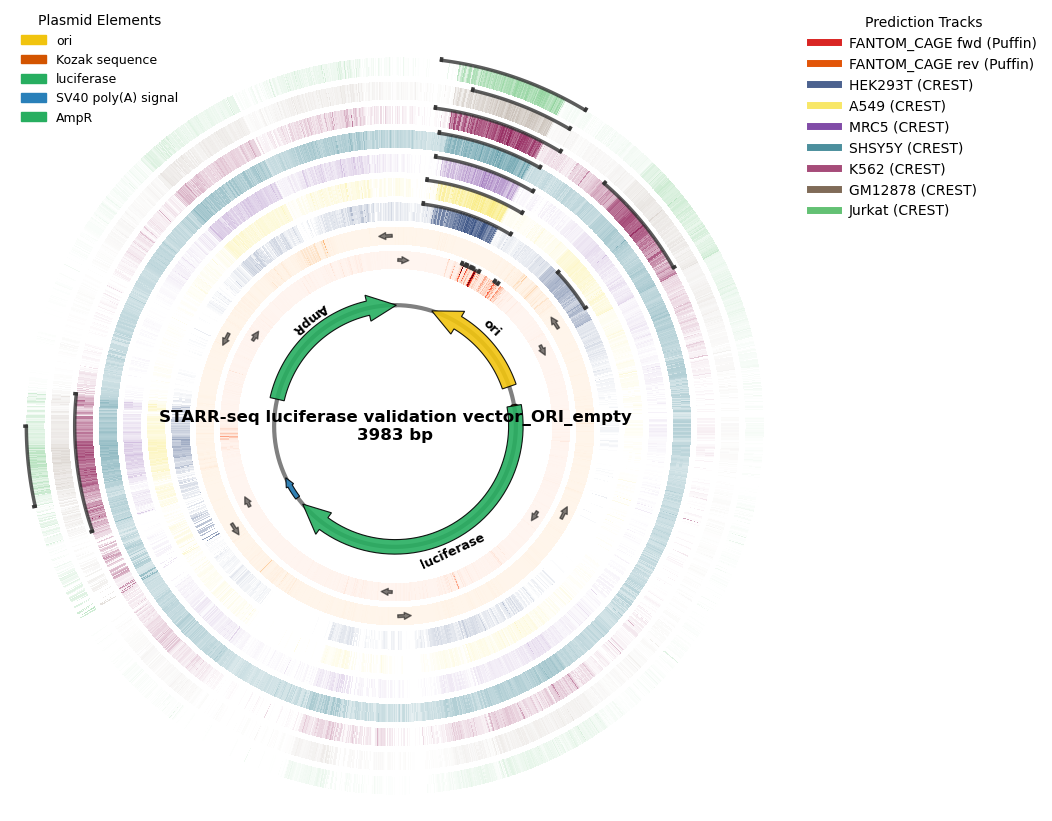

In [7]:
ax = examplots.plot_backbone(gbk_file)
track_width = 0.15  # thickness of each circular heatmap

# Plot Puffin tracks using red/orange sequential colormaps
examplots.plot_track_heatmap(ax, puffin_fwd_preds, cmap="Reds", track_base_radius=1.3, track_width=track_width, track_label="FANTOM_CAGE fwd (Puffin)", k_norm=0.25, direction="cw")
examplots.plot_peak_annotation(ax, plasmid_fwd_tss, seq_len=len(puffin_fwd_preds), track_base_radius=1.3, track_width=track_width)

examplots.plot_track_heatmap(ax, puffin_rev_preds, cmap="Oranges", track_base_radius=1.5, track_width=track_width, track_label="FANTOM_CAGE rev (Puffin)", k_norm=0.25, direction="ccw")
examplots.plot_peak_annotation(ax, plasmid_rev_tss, seq_len=len(puffin_rev_preds), track_base_radius=1.5, track_width=track_width)

# Custom colormaps: exact white at 0, moving to a rich, dark hue at maximum value
crest_cmaps = [
    LinearSegmentedColormap.from_list("c_blue", ["white", "#002060"]),  # Deep Royal Navy
    LinearSegmentedColormap.from_list("c_yellow", ["white", "#f5dd27"]),  # Yellow
    LinearSegmentedColormap.from_list("c_purple", ["white", "#4b0082"]),  # Deep Indigo/Purple
    LinearSegmentedColormap.from_list("c_teal", ["white", "#005f73"]),  # Dark Mediterranean Teal
    LinearSegmentedColormap.from_list("c_magenta", ["white", "#800040"]),  # Deep Wine/Plum Magenta
    LinearSegmentedColormap.from_list("c_brown", ["white", "#4a2c11"]),  # Dark Chocolate Brown
    LinearSegmentedColormap.from_list("c_green", ["white", "#21a639"])  # Forest Green
]

crest_base_r = 1.7  # Starting radius for the first CREST track

for i, cell in enumerate(CELL_TYPES):
    current_radius = crest_base_r + (i * (track_width + 0.05))  # 0.05 padding between rings
    examplots.plot_track_heatmap(ax, plasmid_crest_preds[cell], cmap=crest_cmaps[i], track_base_radius=current_radius, track_width=track_width, track_label=f"{cell} (CREST)", k_norm=6)
    examplots.plot_peak_annotation(ax, plasmid_crest_peaks[cell], seq_len=len(plasmid_crest_preds[cell]), track_base_radius=current_radius, track_width=track_width)

# Render legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.35, 1.05), title="Prediction Tracks", frameon=False)


**Linear Plots: zoom-in**

/projectnb/vtrs/joseff/plasmids/notebooks/../plasmidtools/examplots.py:508: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(FancyArrow(s, y,  span, 0, **arrow_kw))
/projectnb/vtrs/joseff/plasmids/notebooks/../plasmidtools/examplots.py:506: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(FancyArrow(e, y, -span, 0, **arrow_kw))


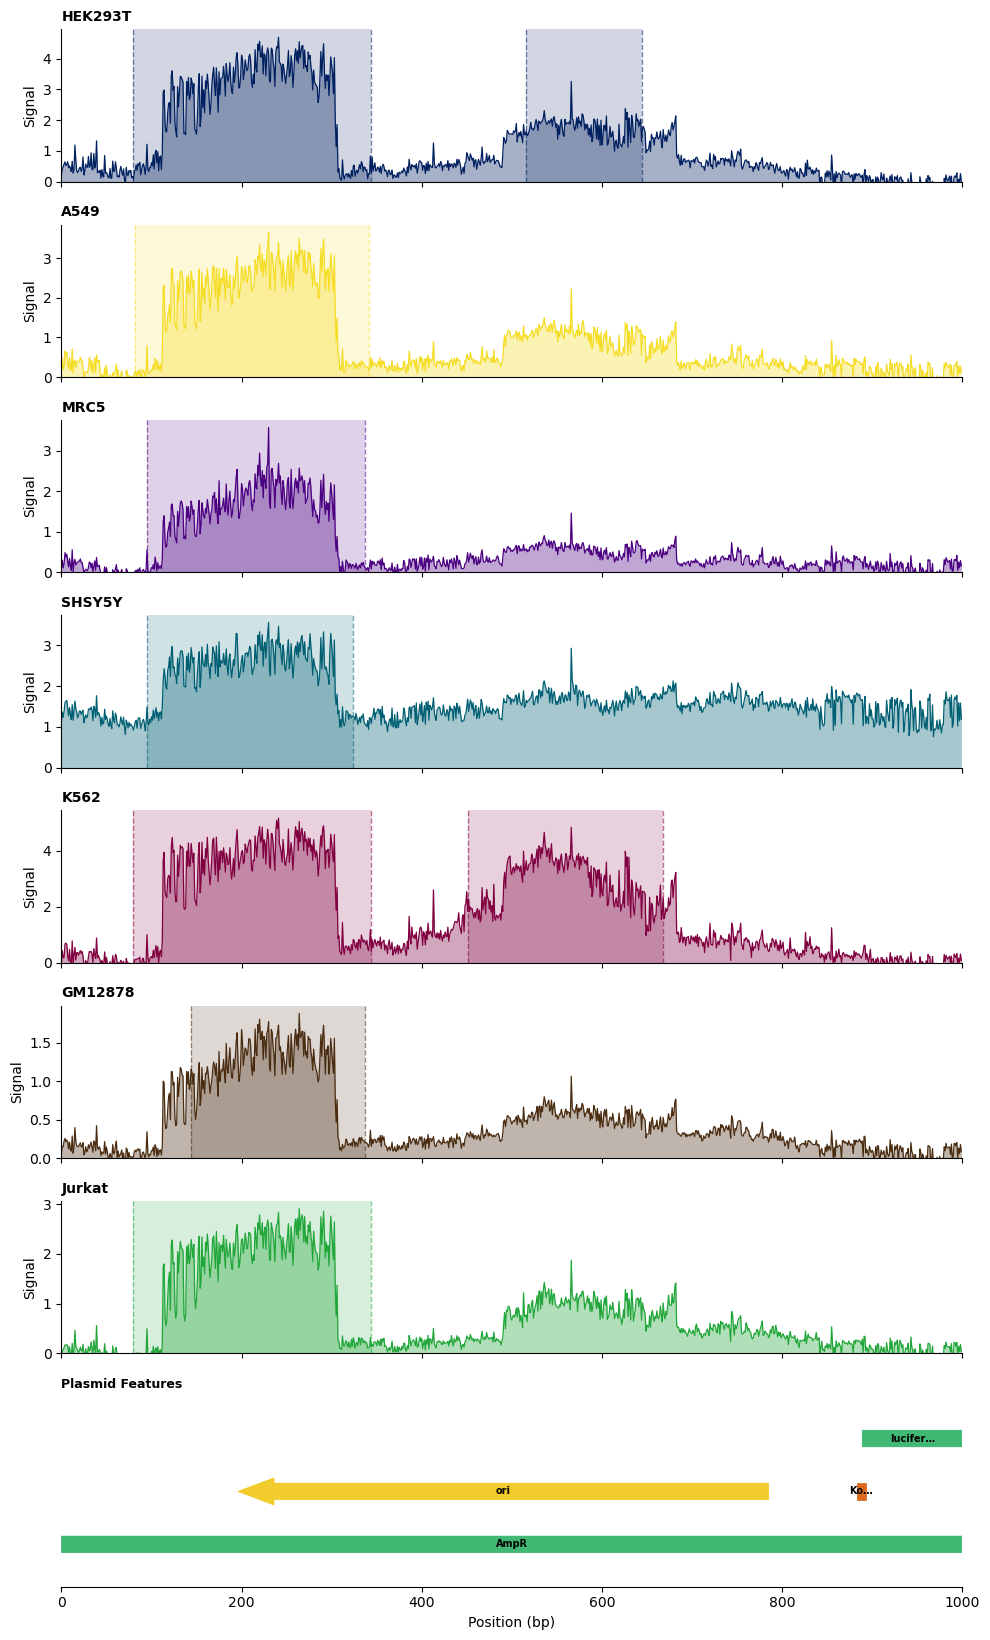

In [8]:
start_bp, end_bp = 0, 1000
colors = ["#002060", "#f5dd27", "#4b0082", "#005f73", "#800040", "#4a2c11", "#21a639"]

# # single track
# examplots.plot_track_linear(
#     plasmid_crest_preds["K562"], 0, 1000,
#     peaks=plasmid_crest_peaks["K562"],
#     label="K562 (CREST)", color="#002060"
# )

n_cells = len(CELL_TYPES)
fig, axes = plt.subplots(
    n_cells + 1, 1,
    figsize=(10, 2.0 * n_cells + 2.5),
    sharex=True,
    gridspec_kw={"height_ratios": [2] * n_cells + [2.5]},
)
fig.subplots_adjust(hspace=0.12)

for ax, cell, color in zip(axes[:-1], CELL_TYPES, colors):
    examplots.plot_track_linear(
        plasmid_crest_preds[cell], start_bp, end_bp,
        peaks=plasmid_crest_peaks[cell],
        label=cell, color=color, ax=ax,
    )
    ax.set_xlabel("")   # suppress x-label on all but the bottom panel

examplots.plot_linear_features(gbk_file, start_bp, end_bp, ax=axes[-1])
plt.tight_layout()